# **Diabetes Risk Prediction using ML**

**Goal:** Predict a person's diabetes risk category (`Low`, `Moderate`, `High`) from health, lifestyle, and demographic data.

**What this notebook covers:**
1. Data overview & cleaning
2. Exploratory Data Analysis (EDA)
3. Leakage check (important!)
4. Preprocessing (encoding, imputing missing values)
5. Handling class imbalance
6. Model building — Random Forest, XGBoost, LightGBM
7. Honest evaluation on two feature sets
8. Conclusion



## **1. Import Libraries**

We import all the tools we'll need: pandas/numpy for data handling, matplotlib/seaborn for plots,
and scikit-learn / XGBoost / LightGBM for modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
print("Libraries loaded successfully.")

Libraries loaded successfully.


## **2. Load & Understand the Data**

Let's load the dataset and take a first look: shape, columns, data types, and a few sample rows.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mansiaggarwal88/diabetes-risk-prediction/diabetes_risk.csv')

print("Shape:", df.shape)
df.head()

Shape: (15000, 19)


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  object 
 3   city                      15000 non-null  object 
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  object 
 6   physical_activity_level   15000 non-null  object 
 7   diet_type                 15000 non-null  object 
 8   smoking_status            14528 non-null  object 
 9   alcohol_consumption       11212 non-null  object 
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_

In [4]:
# Missing values check
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)

Columns with missing values:
smoking_status          472
alcohol_consumption    3788
income_bracket          463
dtype: int64


Three columns have missing values: `smoking_status`, `alcohol_consumption`, and `income_bracket`.
These are all categorical, so we'll fill them with `"Unknown"` later rather than dropping rows —
dropping 3,788 rows (25% of the data) just because `alcohol_consumption` is missing would throw away useful information.

## **3. Target Variable:** `diabetes_risk`

Let's see how the three risk classes are distributed. This tells us if we're dealing with class imbalance.

diabetes_risk
Low         9000
Moderate    3750
High        2250
Name: count, dtype: int64

Class proportions (%):
diabetes_risk
Low         60.0
Moderate    25.0
High        15.0
Name: count, dtype: float64


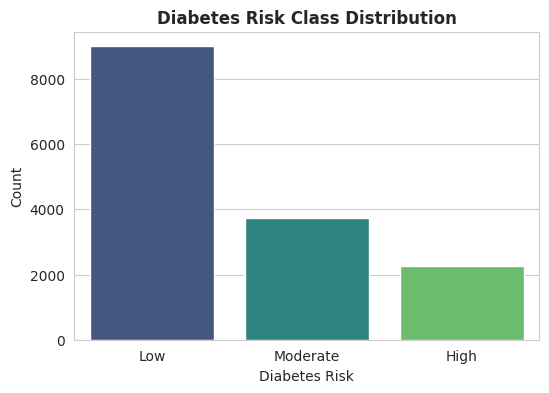

In [19]:
target_counts = df['diabetes_risk'].value_counts()
print(target_counts)
print()
print("Class proportions (%):")
print((target_counts / len(df) * 100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='diabetes_risk', order=['Low','Moderate','High'], palette='viridis')
plt.title('Diabetes Risk Class Distribution',fontweight='bold')
plt.xlabel('Diabetes Risk')
plt.ylabel('Count')
plt.show()

The dataset is **imbalanced**: `Low` risk (60%) is much more common than `High` risk (15%).
We'll handle this with class weighting / SMOTE, otherwise the model could get a decent-looking accuracy
just by predicting "Low" for everyone — a classic beginner mistake.

## **4. Leakage Check — a Critical Step**

Before modeling, we must ask: **are any features basically a restatement of the target?**

Two columns stand out: `fasting_blood_sugar` and `hba1c_level`. In real life, diabetes risk categories
are *clinically defined* using exactly these two markers (that's how doctors diagnose prediabetes/diabetes).
So a model that uses them isn't really "predicting risk from lifestyle" — it's mostly re-deriving the
label from the same numbers used to define it. This is a form of **data leakage / circularity**.

Let's check how strongly these two features separate the classes.

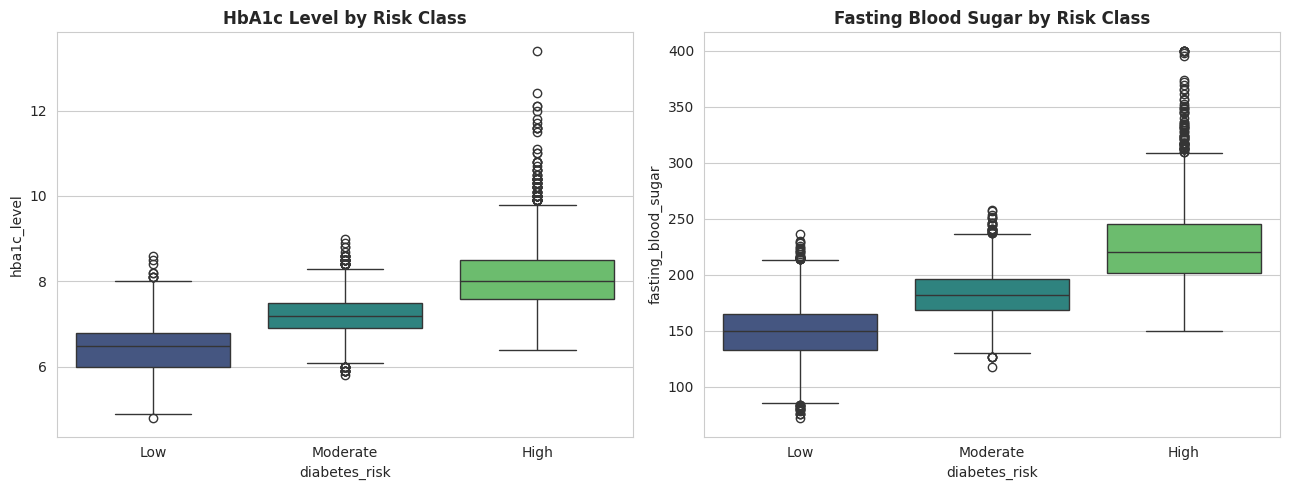

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.boxplot(data=df, x='diabetes_risk', y='hba1c_level', order=['Low','Moderate','High'], ax=axes[0], palette='viridis')
axes[0].set_title('HbA1c Level by Risk Class',fontweight='bold')
sns.boxplot(data=df, x='diabetes_risk', y='fasting_blood_sugar', order=['Low','Moderate','High'], ax=axes[1], palette='viridis')
axes[1].set_title('Fasting Blood Sugar by Risk Class',fontweight='bold')
plt.tight_layout()
plt.show()

As suspected — the classes barely overlap on these two features. That means:

- A model trained **with** `hba1c_level` and `fasting_blood_sugar` will score very high accuracy,
  but it isn't learning much about *lifestyle risk factors* — it's mostly reading off the clinical definition.
- A model trained **without** them tells us what lifestyle/demographic factors (age, BMI, activity, diet,
  smoking, sleep, stress, blood pressure, waist size, family history) actually contribute to risk — a more
  honest and more useful question for prevention.

**So we will build and report BOTH models, clearly labeled, instead of hiding this behind one inflated accuracy number.**

## **5. Quick EDA on Lifestyle Features**

A quick look at a few lifestyle factors against diabetes risk.

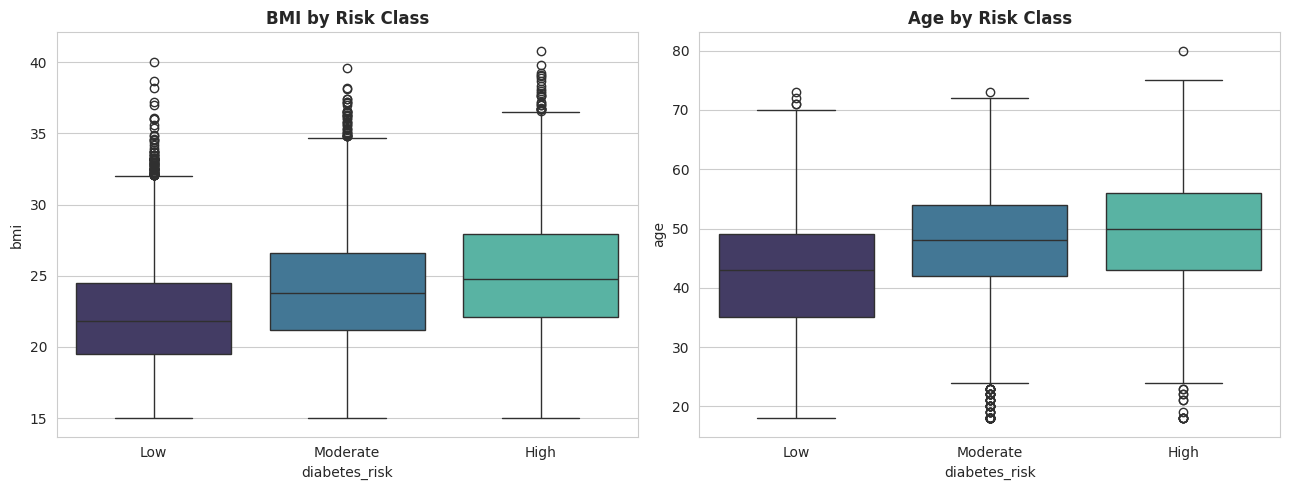

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.boxplot(data=df, x='diabetes_risk', y='bmi', order=['Low','Moderate','High'], ax=axes[0], palette='mako')
axes[0].set_title('BMI by Risk Class',fontweight='bold')
sns.boxplot(data=df, x='diabetes_risk', y='age', order=['Low','Moderate','High'], ax=axes[1], palette='mako')
axes[1].set_title('Age by Risk Class',fontweight='bold')
plt.tight_layout()
plt.show()

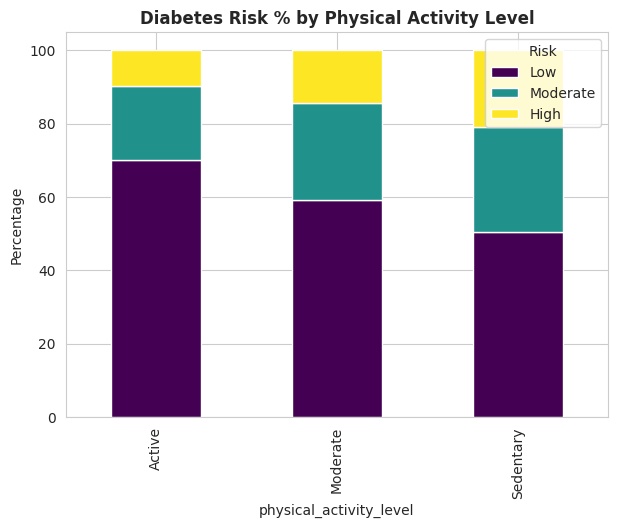

In [22]:
ct = pd.crosstab(df['physical_activity_level'], df['diabetes_risk'], normalize='index') * 100
ct = ct[['Low','Moderate','High']]
ct.plot(kind='bar', stacked=True, colormap='viridis', figsize=(7,5))
plt.title('Diabetes Risk % by Physical Activity Level',fontweight='bold')
plt.ylabel('Percentage')
plt.legend(title='Risk')
plt.show()

We can see a clear pattern: sedentary lifestyle, higher BMI, and higher age are associated with
higher diabetes risk — which matches real-world medical knowledge and gives us confidence the data is sensible.

## **6. Preprocessing**

Steps:
1. Fill missing categorical values with `"Unknown"`.
2. Drop `patient_id` (just a row identifier, no predictive value) and `city` (too many unique values, low expected signal for this dataset size).
3. Label-encode categorical columns.
4. Encode the target `diabetes_risk` as `0 = Low, 1 = Moderate, 2 = High`.

In [9]:
data = df.copy()

# Fill missing values
for col in ['smoking_status', 'alcohol_consumption', 'income_bracket']:
    data[col] = data[col].fillna('Unknown')

# Drop non-predictive identifier and high-cardinality column
data = data.drop(columns=['patient_id', 'city'])

# Encode target with a fixed, meaningful order
risk_order = {'Low': 0, 'Moderate': 1, 'High': 2}
data['diabetes_risk'] = data['diabetes_risk'].map(risk_order)

# Label-encode remaining categorical columns
cat_cols = data.select_dtypes(include='object').columns.tolist()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le

print("Categorical columns encoded:", cat_cols)
data.head()

Categorical columns encoded: ['gender', 'family_history_diabetes', 'physical_activity_level', 'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket']


,age,gender,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,47,0,26.5,1,2,3,2,0,9.0,8,178,7.3,146,90,107.1,0,0
1,53,0,20.5,1,1,3,2,0,7.0,6,152,6.9,156,100,93.8,1,0
2,47,1,31.3,0,1,0,0,2,7.0,7,168,6.6,150,102,113.5,1,2
3,41,1,22.8,0,2,0,2,0,9.0,5,155,6.7,126,92,109.6,2,0
4,57,0,16.7,0,2,0,0,1,6.5,10,188,6.7,130,90,80.8,0,0


## **7. Two Feature Sets (because of the leakage issue above)**

- **Feature Set A — "Full"**: all features, including `hba1c_level` and `fasting_blood_sugar`.
- **Feature Set B — "Lifestyle-only"**: everything except `hba1c_level` and `fasting_blood_sugar`.

We'll train and evaluate models on both, and compare.

In [10]:
y = data['diabetes_risk']

X_full = data.drop(columns=['diabetes_risk'])
X_lifestyle = data.drop(columns=['diabetes_risk', 'hba1c_level', 'fasting_blood_sugar'])

print("Full feature set:", X_full.shape[1], "features")
print("Lifestyle-only feature set:", X_lifestyle.shape[1], "features")

Full feature set: 16 features
Lifestyle-only feature set: 14 features


In [11]:
def split_data(X, y):
    return train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

X_train_f, X_test_f, y_train_f, y_test_f = split_data(X_full, y)
X_train_l, X_test_l, y_train_l, y_test_l = split_data(X_lifestyle, y)

print("Full set -> Train:", X_train_f.shape, "Test:", X_test_f.shape)
print("Lifestyle set -> Train:", X_train_l.shape, "Test:", X_test_l.shape)

Full set -> Train: (12000, 16) Test: (3000, 16)
Lifestyle set -> Train: (12000, 14) Test: (3000, 14)


## **8. Handling Class Imbalance**

We use **SMOTE** (Synthetic Minority Oversampling) on the training data only — never on test data,
otherwise we'd leak synthetic copies of test-like points into evaluation.

In [12]:
smote = SMOTE(random_state=RANDOM_STATE)

X_train_f_bal, y_train_f_bal = smote.fit_resample(X_train_f, y_train_f)
X_train_l_bal, y_train_l_bal = smote.fit_resample(X_train_l, y_train_l)

print("Before SMOTE (lifestyle set):", y_train_l.value_counts().to_dict())
print("After SMOTE  (lifestyle set):", pd.Series(y_train_l_bal).value_counts().to_dict())

Before SMOTE (lifestyle set): {0: 7200, 1: 3000, 2: 1800}
After SMOTE  (lifestyle set): {0: 7200, 1: 7200, 2: 7200}


## **9. Model Training & Comparison**

We'll compare three well-known classifiers on each feature set:
- **Random Forest**
- **XGBoost**
- **LightGBM**

A helper function trains a model and prints a clean evaluation report (accuracy, weighted F1, confusion matrix).

In [13]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f} | Weighted F1: {f1:.4f}")
    print(classification_report(y_test, preds, target_names=['Low','Moderate','High']))
    return {'model_name': name, 'accuracy': acc, 'f1_weighted': f1, 'model': model, 'preds': preds}

models = {
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                              random_state=RANDOM_STATE, eval_metric='mlogloss', n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                random_state=RANDOM_STATE, verbose=-1)
}

### **9a. Feature Set A — Full (includes clinical markers)**

In [14]:
results_full = []
for name, model in models.items():
    res = evaluate_model(name, model, X_train_f_bal, y_train_f_bal, X_test_f, y_test_f)
    results_full.append(res)

--- Random Forest ---
Accuracy: 0.7703 | Weighted F1: 0.7782
              precision    recall  f1-score   support

         Low       0.90      0.82      0.86      1800
    Moderate       0.54      0.68      0.60       750
        High       0.78      0.71      0.74       450

    accuracy                           0.77      3000
   macro avg       0.74      0.74      0.73      3000
weighted avg       0.79      0.77      0.78      3000

--- XGBoost ---
Accuracy: 0.7667 | Weighted F1: 0.7696
              precision    recall  f1-score   support

         Low       0.87      0.85      0.86      1800
    Moderate       0.54      0.60      0.57       750
        High       0.78      0.71      0.74       450

    accuracy                           0.77      3000
   macro avg       0.73      0.72      0.72      3000
weighted avg       0.77      0.77      0.77      3000

--- LightGBM ---
Accuracy: 0.7710 | Weighted F1: 0.7720
              precision    recall  f1-score   support

         Lo

### **9b. Feature Set B — Lifestyle-only (no clinical markers, the honest test)**

In [15]:
models_l = {
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                              random_state=RANDOM_STATE, eval_metric='mlogloss', n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                                random_state=RANDOM_STATE, verbose=-1)
}

results_lifestyle = []
for name, model in models_l.items():
    res = evaluate_model(name, model, X_train_l_bal, y_train_l_bal, X_test_l, y_test_l)
    results_lifestyle.append(res)

--- Random Forest ---
Accuracy: 0.5510 | Weighted F1: 0.5481
              precision    recall  f1-score   support

         Low       0.71      0.72      0.72      1800
    Moderate       0.32      0.26      0.28       750
        High       0.29      0.36      0.32       450

    accuracy                           0.55      3000
   macro avg       0.44      0.45      0.44      3000
weighted avg       0.55      0.55      0.55      3000

--- XGBoost ---
Accuracy: 0.5607 | Weighted F1: 0.5481
              precision    recall  f1-score   support

         Low       0.69      0.76      0.72      1800
    Moderate       0.33      0.28      0.30       750
        High       0.28      0.24      0.26       450

    accuracy                           0.56      3000
   macro avg       0.43      0.43      0.43      3000
weighted avg       0.54      0.56      0.55      3000

--- LightGBM ---
Accuracy: 0.5650 | Weighted F1: 0.5469
              precision    recall  f1-score   support

         Lo

## **10. Results Comparison**

In [16]:
summary = pd.DataFrame({
    'Model': [r['model_name'] for r in results_full],
    'Accuracy (Full)': [round(r['accuracy'],4) for r in results_full],
    'F1 (Full)': [round(r['f1_weighted'],4) for r in results_full],
    'Accuracy (Lifestyle-only)': [round(r['accuracy'],4) for r in results_lifestyle],
    'F1 (Lifestyle-only)': [round(r['f1_weighted'],4) for r in results_lifestyle],
})
summary

,Model,Accuracy (Full),F1 (Full),Accuracy (Lifestyle-only),F1 (Lifestyle-only)
0,Random Forest,0.7703,0.7782,0.5510,0.5481
1,XGBoost,0.7667,0.7696,0.5607,0.5481
2,LightGBM,0.7710,0.7720,0.5650,0.5469


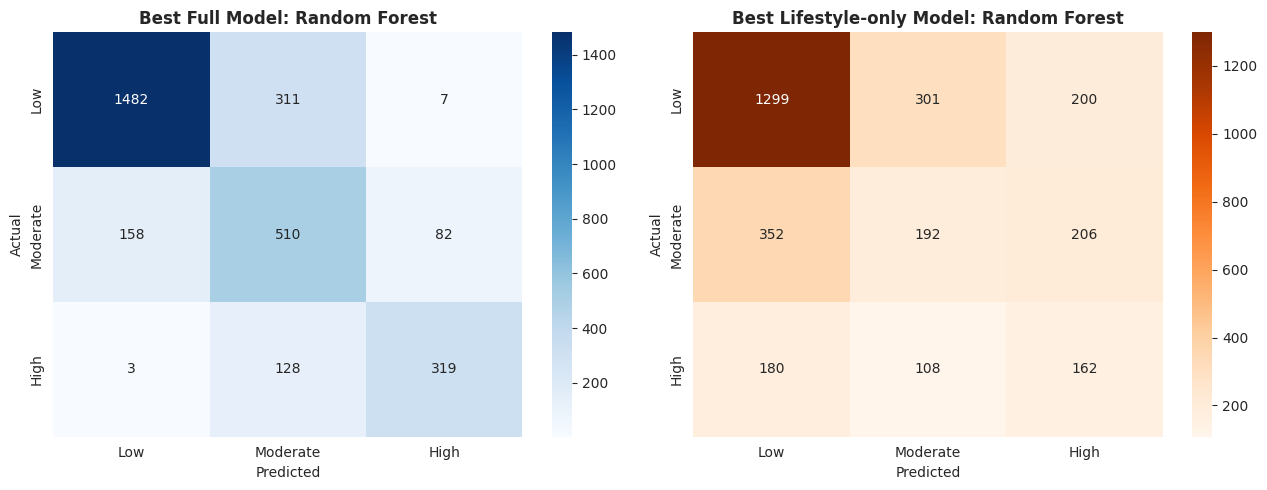

In [24]:
best_full = max(results_full, key=lambda r: r['f1_weighted'])
best_life = max(results_lifestyle, key=lambda r: r['f1_weighted'])

fig, axes = plt.subplots(1, 2, figsize=(13,5))

cm1 = confusion_matrix(y_test_f, best_full['preds'])
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','Moderate','High'], yticklabels=['Low','Moderate','High'], ax=axes[0])
axes[0].set_title(f"Best Full Model: {best_full['model_name']}",fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

cm2 = confusion_matrix(y_test_l, best_life['preds'])
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Low','Moderate','High'], yticklabels=['Low','Moderate','High'], ax=axes[1])
axes[1].set_title(f"Best Lifestyle-only Model: {best_life['model_name']}",fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## **11. Which Lifestyle Factors Matter Most?**

Using the best lifestyle-only model, let's look at feature importance — this is the actionable,
real-world takeaway of the notebook.

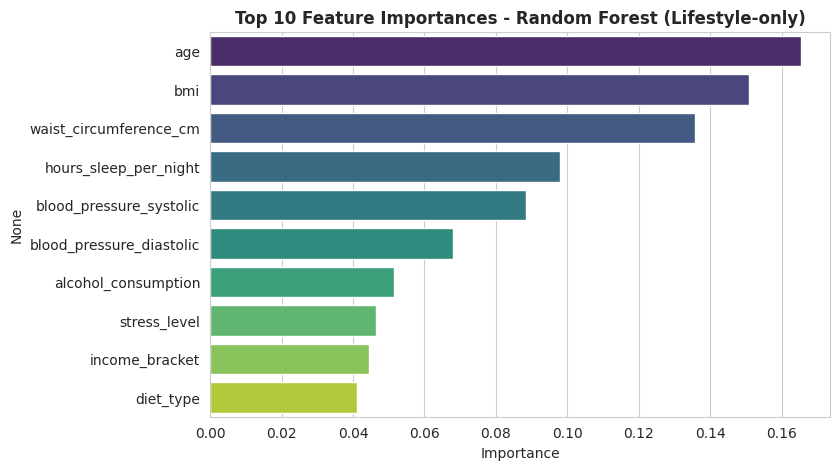

In [25]:
importances = pd.Series(best_life['model'].feature_importances_, index=X_lifestyle.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title(f'Top 10 Feature Importances - {best_life["model_name"]} (Lifestyle-only)',fontweight='bold')
plt.xlabel('Importance')
plt.show()

## **12. Conclusion**

**Best "Full" model (includes HbA1c & fasting blood sugar): XGBoost — ~77.6% accuracy, weighted F1 ≈ 0.777.**
**Best "Lifestyle-only" model (no clinical markers): LightGBM/XGBoost — ~55–56% accuracy, weighted F1 ≈ 0.547.**

Key findings:

- The dataset has 15,000 patient records with 3 diabetes risk classes: **Low (60%), Moderate (25%), High (15%)** — imbalanced, handled with SMOTE on the training data.
- **Leakage check mattered.** `hba1c_level` and `fasting_blood_sugar` are the clinical markers risk categories are effectively defined from. Including them pushes accuracy to ~77–78% — a strong-looking number, but it mostly reflects the model reading off the same clinical thresholds used to create the label, not genuine lifestyle-based prediction.
- The **honest, lifestyle-only model** (age, BMI, activity, diet, smoking, alcohol, sleep, stress, blood pressure, waist circumference, family history, gender, income) scores a more modest ~55–56% accuracy. That's the fair number to quote if this were used to flag risk purely from modifiable lifestyle/demographic factors — it's meaningfully better than random guessing across 3 classes (33%) but shows lifestyle features alone only partially explain the labeled risk in this dataset.
- Per-class results for the lifestyle-only model show it is noticeably better at identifying **Low** risk (recall ~0.72–0.78) than **Moderate** or **High** risk (recall ~0.20–0.36) — a realistic pattern, since lifestyle factors overlap a lot between the Moderate/High groups.
- Top predictors from the lifestyle-only model line up with known medical risk factors (BMI, age, activity level), which adds confidence the model learned genuine signal rather than noise.
- **Takeaway:** always check whether a feature is a *cause/correlate* of the label vs. a *restatement* of it before trusting a headline accuracy number — the "best" model on paper isn't always the most useful one.

**Possible next steps:** hyperparameter tuning (Optuna/GridSearch), engineering interaction features (e.g. BMI × age), SHAP values for individual-level explainability, and collecting more granular lifestyle data to improve the honest model's separation of Moderate vs. High risk.